##  Initial visualisation for 2D ice sheet model output data: IMAU_UFEMISM1

#### Watch out for: Full model area seems to be flagged as floating? Problems reading in coordinates

In [1]:
import numpy as np
import xarray as xr
from matplotlib import pylab as plt
import pandas as pd

/home/mkjs0/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
basepath = '/home/mkjs0/mount/gadi/'
model = 'IMAU_UFEMISM1'
model_base = 'AIS_' + model # this is the text (stays the same) in the actual data file that incorporates the model and usually AIS
model_reso = '32'
pth_scalar_values = '/home/mkjs0/research/python/hackathon/ComputedScalars'

# 1. Check CTRL run

In [3]:
# File paths for CTRL run
exp1='ctrlAE_'+model_reso
exp2='ctrlAE'

mask_floating = 'sftflf_' + model_base + '_' + exp2 + '.nc'
draft = 'base_' + model_base + '_' + exp2 + '.nc'
bmboutput = 'libmassbffl_' + model_base + '_' + exp2 + '.nc'
smb = 'acabf_' + model_base + '_' + exp2 + '.nc'
bed = 'topg_' + model_base + '_' + exp2 + '.nc'
thk = 'lithk_' + model_base + '_' + exp2 + '.nc'
area = 'iareafl_'+ model_base + '_' + exp2 + '.nc'

In [4]:
d =xr.open_dataset(basepath+model +'/'+exp1+'/'+mask_floating)

### 1a. Check start and end times and timestep

In [5]:
# check start and end dates of simulations
print('start date: ' + d.time.values[0].strftime().split(' ')[0])
print('end date: ' + d.time.values[-1].strftime().split(' ')[0])

dt = np.zeros([d.time.size-1,1])

for i in range(d.time.size-1):
    delta=d.time[i+1]-d.time[i]
    dt[i]=delta.values

check= np.unique(dt)

if len(check)==1:  
    print('Timestep is consistent: ',check/8.64e13,' days')
else:
    print('Multiple timesteps found: ',check/8.64e13,' days')

start date: 2015-01-01
end date: 2300-01-01
Timestep is consistent:  [360.]  days


### 1b. Is grid equi distant?


In [6]:
dx_array =d.x.values[1:]-d.x.values[:-1]
dx= np.unique(dx_array)
if len(dx)==1:  
    print('Consistent x resolution of ',dx,' m')
else:
    print('Warning: Uneven grid detected')
dy_array =d.y.values[1:]-d.y.values[:-1]
dy = np.unique(dy_array)
if len(dy)==1:
 
    print('Consistent y resolution of ',dy,' m')
else:
    print('Warning: Uneven grid detected')
dx=dx[0]
dy=dy[0]

Consistent x resolution of  [0.]  m
Consistent y resolution of  [0.]  m


The coordinates in the dataset cannot be read, all displayed as 9.969e+36

### 1c. Check floating mask

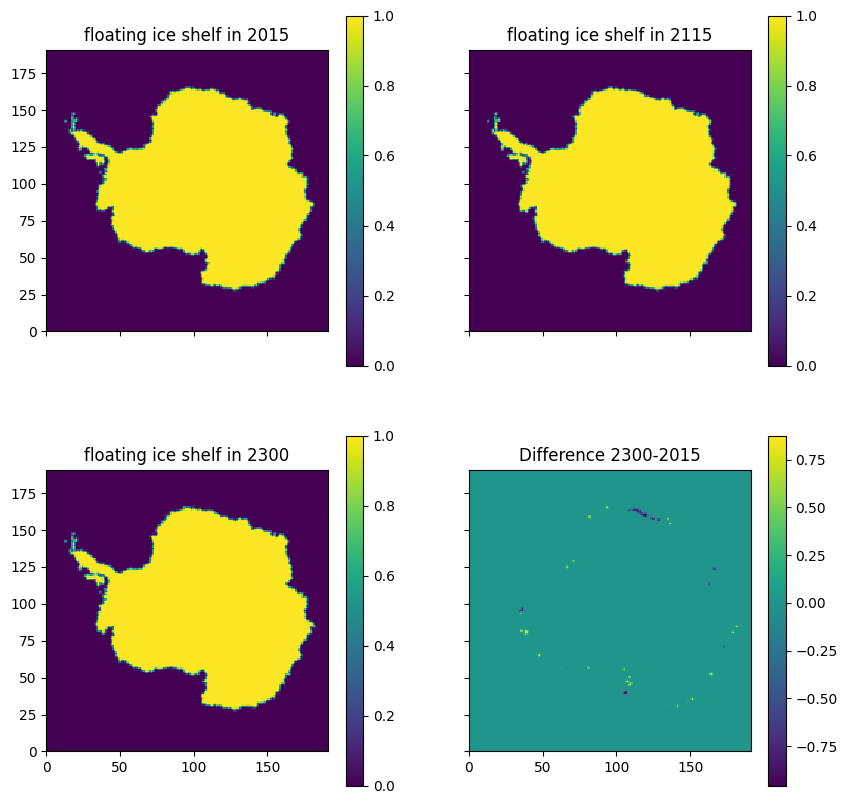

In [7]:
mask = d

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize = (10, 10), sharex = True, sharey = True)

pcm1 = ax1.pcolormesh(mask.sftflf[0,:], cmap='viridis', shading='auto')
pcm2 = ax2.pcolormesh(mask.sftflf[100,:], cmap='viridis', shading='auto')
pcm3 = ax3.pcolormesh(mask.sftflf[-1,:], cmap='viridis', shading='auto')

diff = mask.sftflf[-1,:,:] - mask.sftflf[0,:,:]
pcm4 = ax4.pcolormesh(diff, cmap='viridis', shading='auto')

fig.colorbar(pcm1, ax=ax1)
fig.colorbar(pcm2, ax=ax2)
fig.colorbar(pcm3, ax=ax3)
fig.colorbar(pcm4, ax=ax4)

ax1.set_title('floating ice shelf in 2015')
ax2.set_title('floating ice shelf in 2115')
ax3.set_title('floating ice shelf in 2300')
ax4.set_title('Difference 2300-2015')

[ax.set_ylabel('') for ax in [ax1, ax2, ax3, ax4]]
[ax.set_xlabel('') for ax in [ax1, ax2, ax3, ax4]]

ax1.set_aspect('equal') 
ax2.set_aspect('equal') 
ax3.set_aspect('equal') 
ax4.set_aspect('equal') 

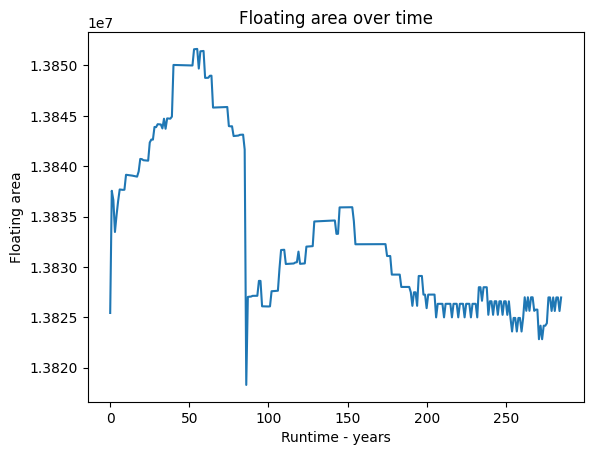

In [8]:
grid_area = int(model_reso)**2
ts = np.nansum(mask.sftflf, axis=(1,2) )*grid_area

plt.figure()
plt.title('Floating area over time')
plt.plot(ts)
plt.xlabel('Runtime - years')
plt.ylabel('Floating area')
plt.show()

### 1d. Check ice thickness

In [9]:
d_draft =xr.open_dataset(basepath+model +'/'+exp1 +'/'+draft)
d_thk = xr.open_dataset(basepath+model +'/'+exp1 +'/'+thk)

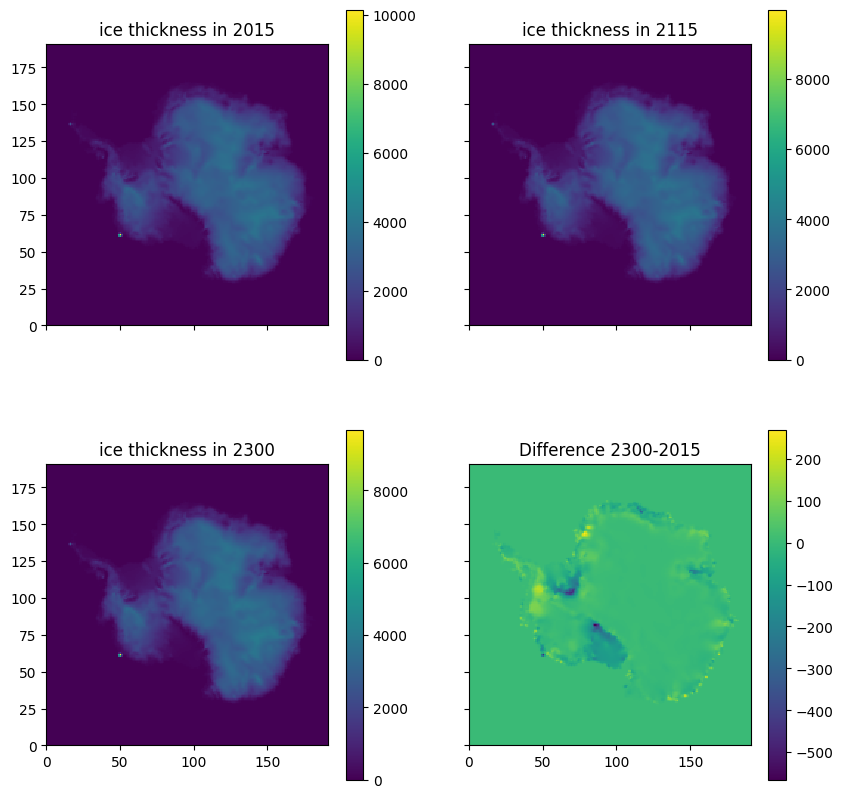

In [10]:
mask = d_thk


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize = (10, 10), sharex = True, sharey = True)

pcm1 = ax1.pcolormesh(mask.lithk[0,:], cmap='viridis', shading='auto')#,vmin=0, vmax=8000)
pcm2 = ax2.pcolormesh(mask.lithk[100,:], cmap='viridis', shading='auto')#,vmin=0, vmax=8000)
pcm3 = ax3.pcolormesh(mask.lithk[-1,:], cmap='viridis', shading='auto')#,vmin=0, vmax=8000)

diff = mask.lithk[-1,:,:] - mask.lithk[0,:,:]
pcm4 = ax4.pcolormesh(diff, cmap='viridis', shading='auto')

fig.colorbar(pcm1, ax=ax1)
fig.colorbar(pcm2, ax=ax2)
fig.colorbar(pcm3, ax=ax3)
fig.colorbar(pcm4, ax=ax4)

ax1.set_title('ice thickness in 2015')
ax2.set_title('ice thickness in 2115')
ax3.set_title('ice thickness in 2300')
ax4.set_title('Difference 2300-2015')

[ax.set_ylabel('') for ax in [ax1, ax2, ax3, ax4]]
[ax.set_xlabel('') for ax in [ax1, ax2, ax3, ax4]]

ax1.set_aspect('equal') 
ax2.set_aspect('equal') 
ax3.set_aspect('equal') 
ax4.set_aspect('equal') 


### 1e.  Is ice shelf draft negative for floating mask?

In [11]:
# Prints warning if ice shelf draft is above sea level

ts = np.zeros([d.time.size,1])

for i in range(d.time.size):
    m_in = d.isel(time =i).sftflf #.values
    m = m_in ==1
    shelf_draft =d_draft.base.values[i,]
    mpos = shelf_draft[m]>0
    ts[i] = np.nanmean(shelf_draft[m])
    if mpos.sum()>0:
        print('Warning: Found floating draft value above sea level! ', 'Year: ',d.time.values[i],', Draft (m): ',np.mean(mpos))


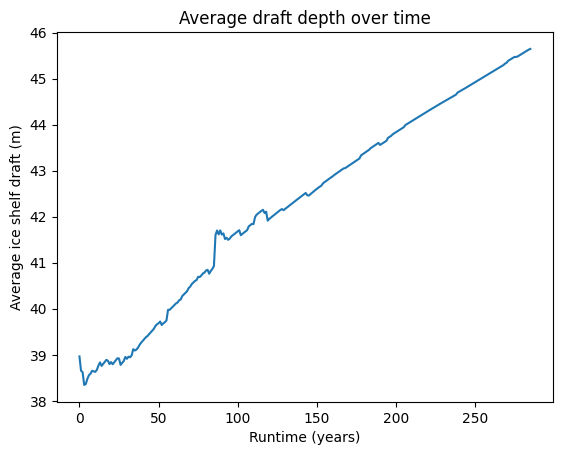

In [12]:
plt.figure()
plt.plot(ts)
plt.title('Average draft depth over time')
plt.xlabel('Runtime (years)')
plt.ylabel('Average ice shelf draft (m)')
plt.show()

###  1f.  What are max and min BMB values? There should be very limited +ve values

In [13]:
d_bmb=xr.open_dataset(basepath+model +'/'+exp1 +'/'+bmboutput)
bmb = d_bmb.libmassbffl.values[0,]*365*24*60*60/917
print('Min BMB (melting):', np.nanmin(bmb), 'm/a')
print('Max BMB (refreezing):', np.nanmax(bmb), 'm/a')

Min BMB (melting): -9.333171 m/a
Max BMB (refreezing): 8.2238626e-11 m/a


### 1g. Plot example BMB for West Antarctica

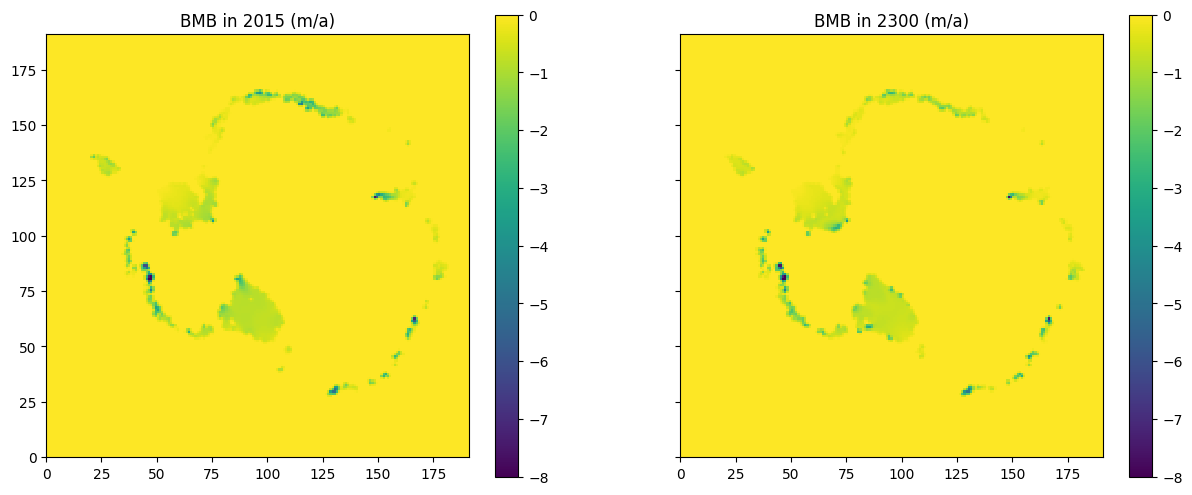

In [14]:
fig, ((ax1, ax2)) = plt.subplots(1,2, figsize = (15, 6), sharex = True, sharey = True)
mask = d_bmb
pcm1 = ax1.pcolormesh(mask.libmassbffl[0,:]* 365 * 24 * 60 * 60 / 917, cmap='viridis', shading='auto',vmin=-8, vmax=0)
pcm2 = ax2.pcolormesh(mask.libmassbffl[-1,:]* 365 * 24 * 60 * 60 / 917, cmap='viridis', shading='auto',vmin=-8, vmax=0)
fig.colorbar(pcm1, ax=ax1)
fig.colorbar(pcm2, ax=ax2)
#diff.plot(ax = ax4)

ax1.set_title('BMB in 2015 (m/a)')
ax2.set_title('BMB in 2300 (m/a)')


ax1.set_aspect('equal') 
ax2.set_aspect('equal') 


### 1h. Check for basal melt on grounded cells ?

In [15]:
# Prints warning if melt is found on grounded cells

for i in range(d.time.size):
    m_in=d.sftflf.values[i,]
    m = m_in ==0
    bmb_grounded=d_bmb.libmassbffl.values[i,]
    mpos = bmb_grounded[m]>0
    if mpos.sum()>0:
        print('Warning: basal melting recorded on fully grounded cells ' ,years[i])

### 1i. Plot total BMB over time

Text(0.5, 0, 'Runtime - years')

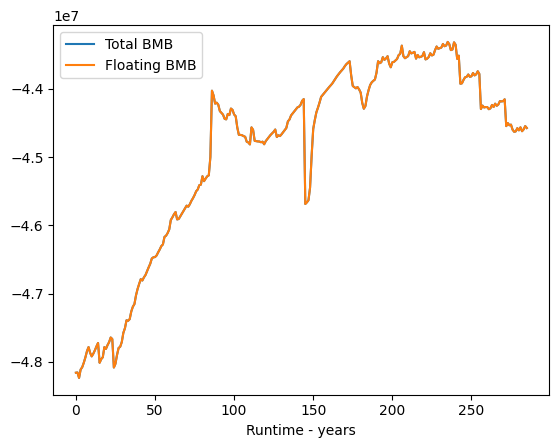

In [16]:
tendlibmassbf = 'tendlibmassbf_' + model_base + '_' + exp2 + '.nc'
tendlibmassbffl = 'tendlibmassbffl_' + model_base + '_' + exp2 + '.nc'

dbmb1 =xr.open_dataset(basepath + '/' + model + '/' + exp1 + '/' + tendlibmassbf)
dbmb2 =xr.open_dataset(basepath + '/' + model + '/' + exp1 + '/' + tendlibmassbffl)

line1, = plt.plot(dbmb1.tendlibmassbf, label='Total BMB')
line2, = plt.plot(dbmb2.tendlibmassbffl, label='Floating BMB')
plt.legend()
plt.xlabel('Runtime - years')

If the total and floating BMB lines are different - there is basal melting of grounded ice

# 2. Check experiment ExpAE05

In [17]:
# File paths for expAE05
exp1='expAE05_'+model_reso
exp2='expAE05'

mask_floating = 'sftflf_' + model_base + '_' + exp2 + '.nc'
draft = 'base_' + model_base + '_' + exp2 + '.nc'
bmboutput = 'libmassbffl_' + model_base + '_' + exp2 + '.nc'
smb = 'acabf_' + model_base + '_' + exp2 + '.nc'
bed = 'topg_' + model_base + '_' + exp2 + '.nc'
thk = 'lithk_' + model_base + '_' + exp2 + '.nc'

In [18]:
d =xr.open_dataset(basepath+model +'/'+exp1+'/'+mask_floating)

### 2a. Check start and end times

In [19]:
# check start and end dates of simulations
print('start date: ' + d.time.values[0].strftime().split(' ')[0])
print('end date: ' + d.time.values[-1].strftime().split(' ')[0])

dt = np.zeros([d.time.size-1,1])

for i in range(d.time.size-1):
    delta=d.time[i+1]-d.time[i]
    dt[i]=delta.values

check= np.unique(dt)

if len(check)==1:  
    print('Timestep is consistent: ',check/8.64e13,' days')
else:
    print('Multiple timesteps found: ',check/8.64e13,' days')

start date: 2015-01-01
end date: 2300-01-01
Timestep is consistent:  [360.]  days


### 2b. Is grid equi distant?


In [20]:
dx_array =d.x.values[1:]-d.x.values[:-1]
dx= np.unique(dx_array)
if len(dx)==1:  
    print('Consistent x resolution of ',dx,' m')
else:
    print('Warning: Uneven grid detected')
dy_array =d.y.values[1:]-d.y.values[:-1]
dy = np.unique(dy_array)
if len(dy)==1:
 
    print('Consistent y resolution of ',dy,' m')
else:
    print('Warning: Uneven grid detected')
dx=dx[0]
dy=dy[0]

Consistent x resolution of  [0.]  m
Consistent y resolution of  [0.]  m


### 2c. Check floating mask

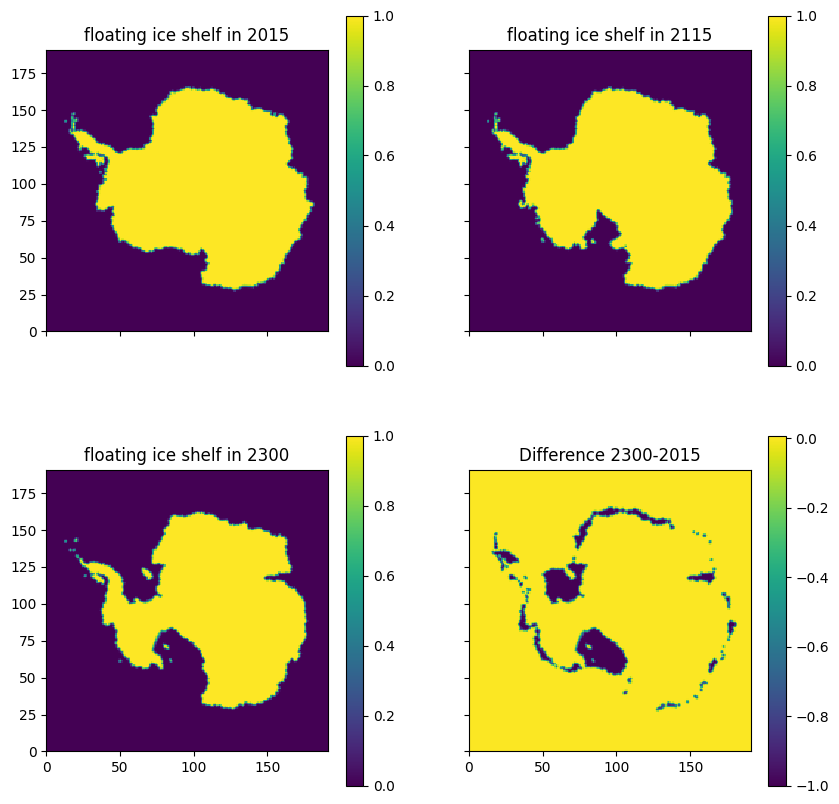

In [21]:
mask = d

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize = (10, 10), sharex = True, sharey = True)

pcm1 = ax1.pcolormesh(mask.sftflf[0,:], cmap='viridis', shading='auto')
pcm2 = ax2.pcolormesh(mask.sftflf[100,:], cmap='viridis', shading='auto')
pcm3 = ax3.pcolormesh(mask.sftflf[-1,:], cmap='viridis', shading='auto')

diff = mask.sftflf[-1,:,:] - mask.sftflf[0,:,:]
pcm4 = ax4.pcolormesh(diff, cmap='viridis', shading='auto')

fig.colorbar(pcm1, ax=ax1)
fig.colorbar(pcm2, ax=ax2)
fig.colorbar(pcm3, ax=ax3)
fig.colorbar(pcm4, ax=ax4)

ax1.set_title('floating ice shelf in 2015')
ax2.set_title('floating ice shelf in 2115')
ax3.set_title('floating ice shelf in 2300')
ax4.set_title('Difference 2300-2015')

[ax.set_ylabel('') for ax in [ax1, ax2, ax3, ax4]]
[ax.set_xlabel('') for ax in [ax1, ax2, ax3, ax4]]

ax1.set_aspect('equal') 
ax2.set_aspect('equal') 
ax3.set_aspect('equal') 
ax4.set_aspect('equal') 

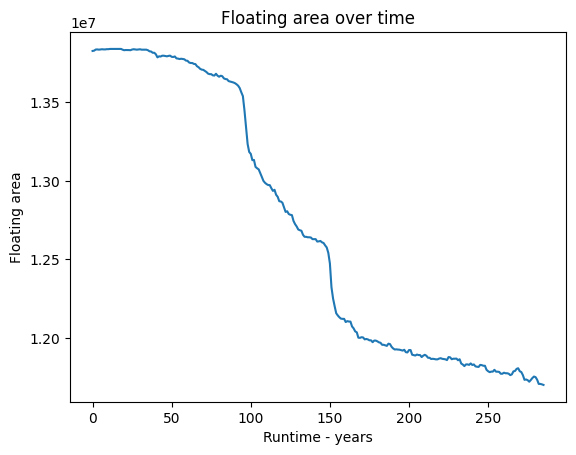

In [22]:
grid_area = int(model_reso)**2
ts = np.nansum(mask.sftflf, axis=(1,2) )*grid_area

plt.figure()
plt.title('Floating area over time')
plt.plot(ts)
plt.xlabel('Runtime - years')
plt.ylabel('Floating area')
plt.show()

### 2d. Check ice thickness

In [23]:
d_draft =xr.open_dataset(basepath+model +'/'+exp1 +'/'+draft)
d_thk = xr.open_dataset(basepath+model +'/'+exp1 +'/'+thk)

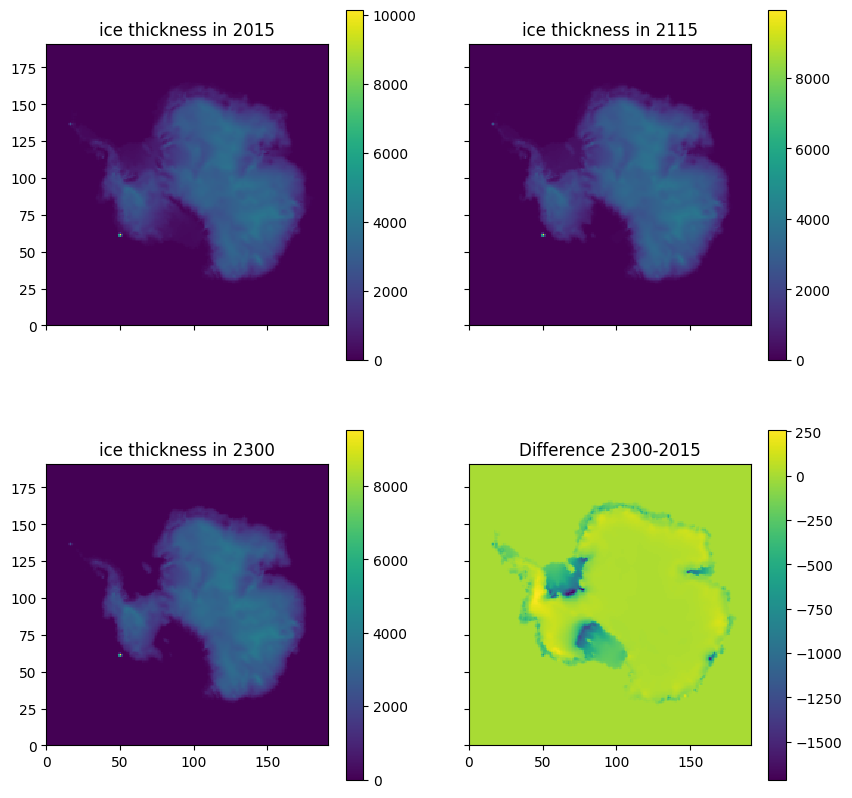

In [24]:
mask = d_thk

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize = (10, 10), sharex = True, sharey = True)

pcm1 = ax1.pcolormesh(mask.lithk[0,:], cmap='viridis', shading='auto')#,vmin=0, vmax=8000)
pcm2 = ax2.pcolormesh(mask.lithk[100,:], cmap='viridis', shading='auto')#,vmin=0, vmax=8000)
pcm3 = ax3.pcolormesh(mask.lithk[-1,:], cmap='viridis', shading='auto')#,vmin=0, vmax=8000)

diff = mask.lithk[-1,:,:] - mask.lithk[0,:,:]
pcm4 = ax4.pcolormesh(diff, cmap='viridis', shading='auto')

fig.colorbar(pcm1, ax=ax1)
fig.colorbar(pcm2, ax=ax2)
fig.colorbar(pcm3, ax=ax3)
fig.colorbar(pcm4, ax=ax4)

ax1.set_title('ice thickness in 2015')
ax2.set_title('ice thickness in 2115')
ax3.set_title('ice thickness in 2300')
ax4.set_title('Difference 2300-2015')

[ax.set_ylabel('') for ax in [ax1, ax2, ax3, ax4]]
[ax.set_xlabel('') for ax in [ax1, ax2, ax3, ax4]]

ax1.set_aspect('equal') 
ax2.set_aspect('equal') 
ax3.set_aspect('equal') 
ax4.set_aspect('equal') 

### 2e.  Is ice shelf draft negative for floating mask?

In [25]:
# Prints warning if ice shelf draft is above sea level

ts = np.zeros([d.time.size,1])

for i in range(d.time.size):
    m_in = d.isel(time =i).sftflf #.values
    m = m_in ==1
    shelf_draft =d_draft.base.values[i,]
    mpos = shelf_draft[m]>0
    ts[i] = np.nanmean(shelf_draft[m])
    if mpos.sum()>0:
        print('Warning: Found floating draft value above sea level! ', 'Year: ',d.time.values[i],', Draft (m): ',np.mean(mpos))
        

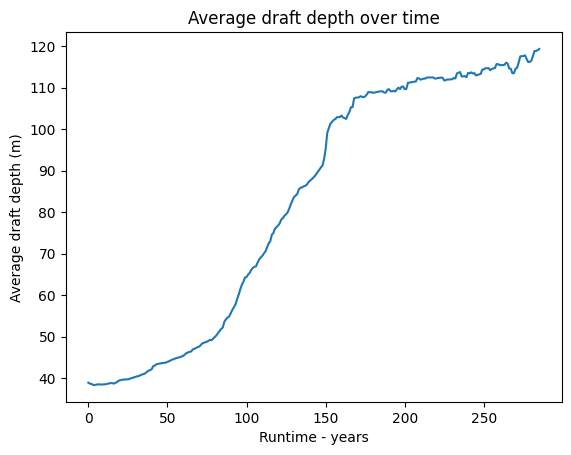

In [26]:
plt.figure()
plt.plot(ts)
plt.title('Average draft depth over time')
plt.xlabel('Runtime - years')
plt.ylabel('Average draft depth (m)')
plt.show()

###  2f.  What are max and min BMB values? There should be very limited +ve values

In [27]:
d_bmb=xr.open_dataset(basepath+model +'/'+exp1 +'/'+bmboutput)
bmb = d_bmb.libmassbffl.values[0,]*365*24*60*60/917
print('Min BMB (melting):', np.nanmin(bmb), 'm/a')
print('Max BMB (refreezing):', np.nanmax(bmb), 'm/a')

Min BMB (melting): -9.028027 m/a
Max BMB (refreezing): 0.014309216 m/a


### 2g. Plot example BMB for West Antarctica

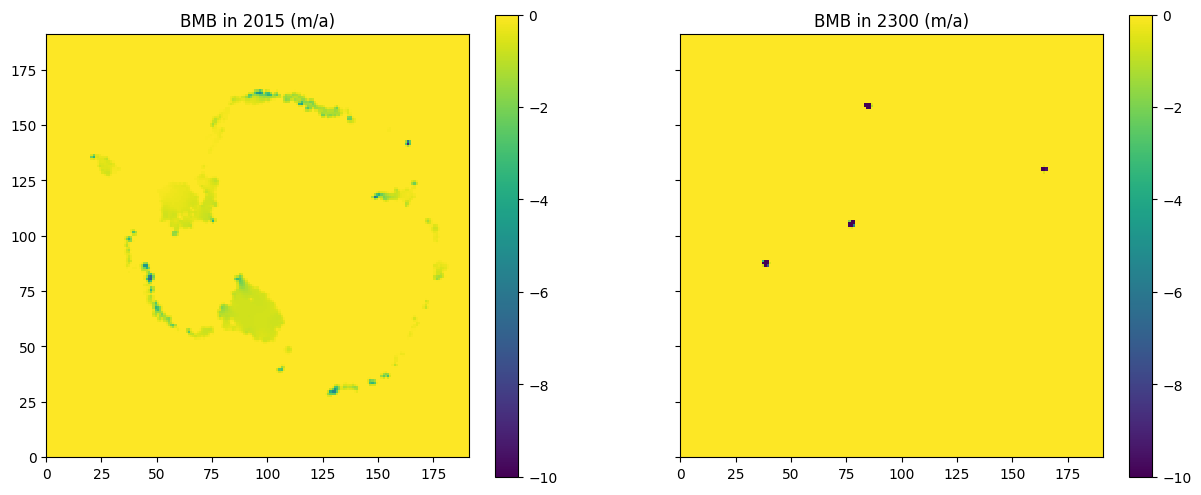

In [28]:
fig, ((ax1, ax2)) = plt.subplots(1,2, figsize = (15, 6), sharex = True, sharey = True)
mask = d_bmb
pcm1 = ax1.pcolormesh(mask.libmassbffl[0,:]* 365 * 24 * 60 * 60 / 917, cmap='viridis', shading='auto',vmin=-10, vmax=0)
pcm2 = ax2.pcolormesh(mask.libmassbffl[-1,:]* 365 * 24 * 60 * 60 / 917, cmap='viridis', shading='auto',vmin=-10, vmax=0)
fig.colorbar(pcm1, ax=ax1)
fig.colorbar(pcm2, ax=ax2)

ax1.set_title('BMB in 2015 (m/a)')
ax2.set_title('BMB in 2300 (m/a)')

ax1.set_aspect('equal') 
ax2.set_aspect('equal') 

### 2h. Check for basal melt on grounded cells

In [29]:
years = d.time.dt.year.values
for i in range(d.time.size):
    m_in=d.sftflf.values[i,]
    m = m_in ==0
    bmb_grounded=d_bmb.libmassbffl.values[i,]
    mpos = bmb_grounded[m]>0
    if mpos.sum()>0:
        print('Warning: basal melt recorded on fully grounded cells ' ,years[i])

### 2i. Plot total BMB over time

Text(0.5, 0, 'Runtime - years')

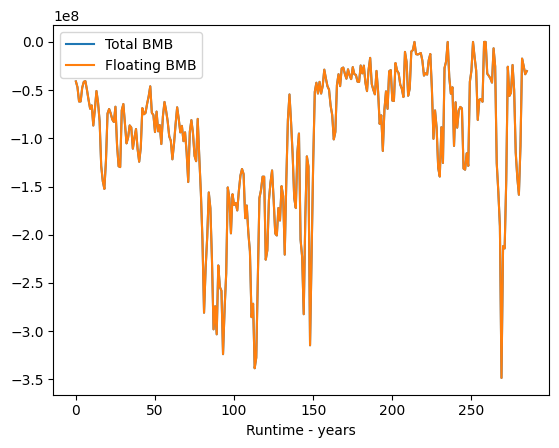

In [30]:
tendlibmassbf = 'tendlibmassbf_' + model_base + '_' + exp2 + '.nc'
tendlibmassbffl = 'tendlibmassbffl_' + model_base + '_' + exp2 + '.nc'

dbmb1 =xr.open_dataset(basepath + '/' + model + '/' + exp1 + '/' + tendlibmassbf)
dbmb2 =xr.open_dataset(basepath + '/' + model + '/' + exp1 + '/' + tendlibmassbffl)

line1, = plt.plot(dbmb1.tendlibmassbf, label='Total BMB')
line2, = plt.plot(dbmb2.tendlibmassbffl, label='Floating BMB')
plt.legend()
plt.xlabel('Runtime - years')

If the total and floating BMB lines are different - there is grounded melting